In [18]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

In [2]:
manifold_type = 'S2'

G_sampler_ls = [
    get_G_class(manifold_type, sampler, name, params) for sampler, name, params 
        in [
            (uniform_sampler, 'uniform', None),
            (multimodal_sampler, '1-modal', {'tau2' : 0.05, 'num_modes' : 1}),
            (multimodal_sampler, '4-modal', {'tau2' : 0.01, 'num_modes' : 4}),
            (equator_sampler, 'equator', {'tau2' : 0.001})         
        ]
    ]



In [5]:
NMC = 3
n_samples = 500
sigma2_ls = np.linspace(0.005, 0.25, 5)
num_oracle_samples = 10000
oracle_bandwidth = 0.25
# ------------------------------------------------------------------------------------------------------------------------------------------------
df_sigma = mcsims_IncreasingSigma(
    manifold_type,
    n_samples,
    G_sampler_ls,
    sigma2_ls,
    num_oracle_samples,
    oracle_bandwidth,
    NMC, 
    bayes=False)

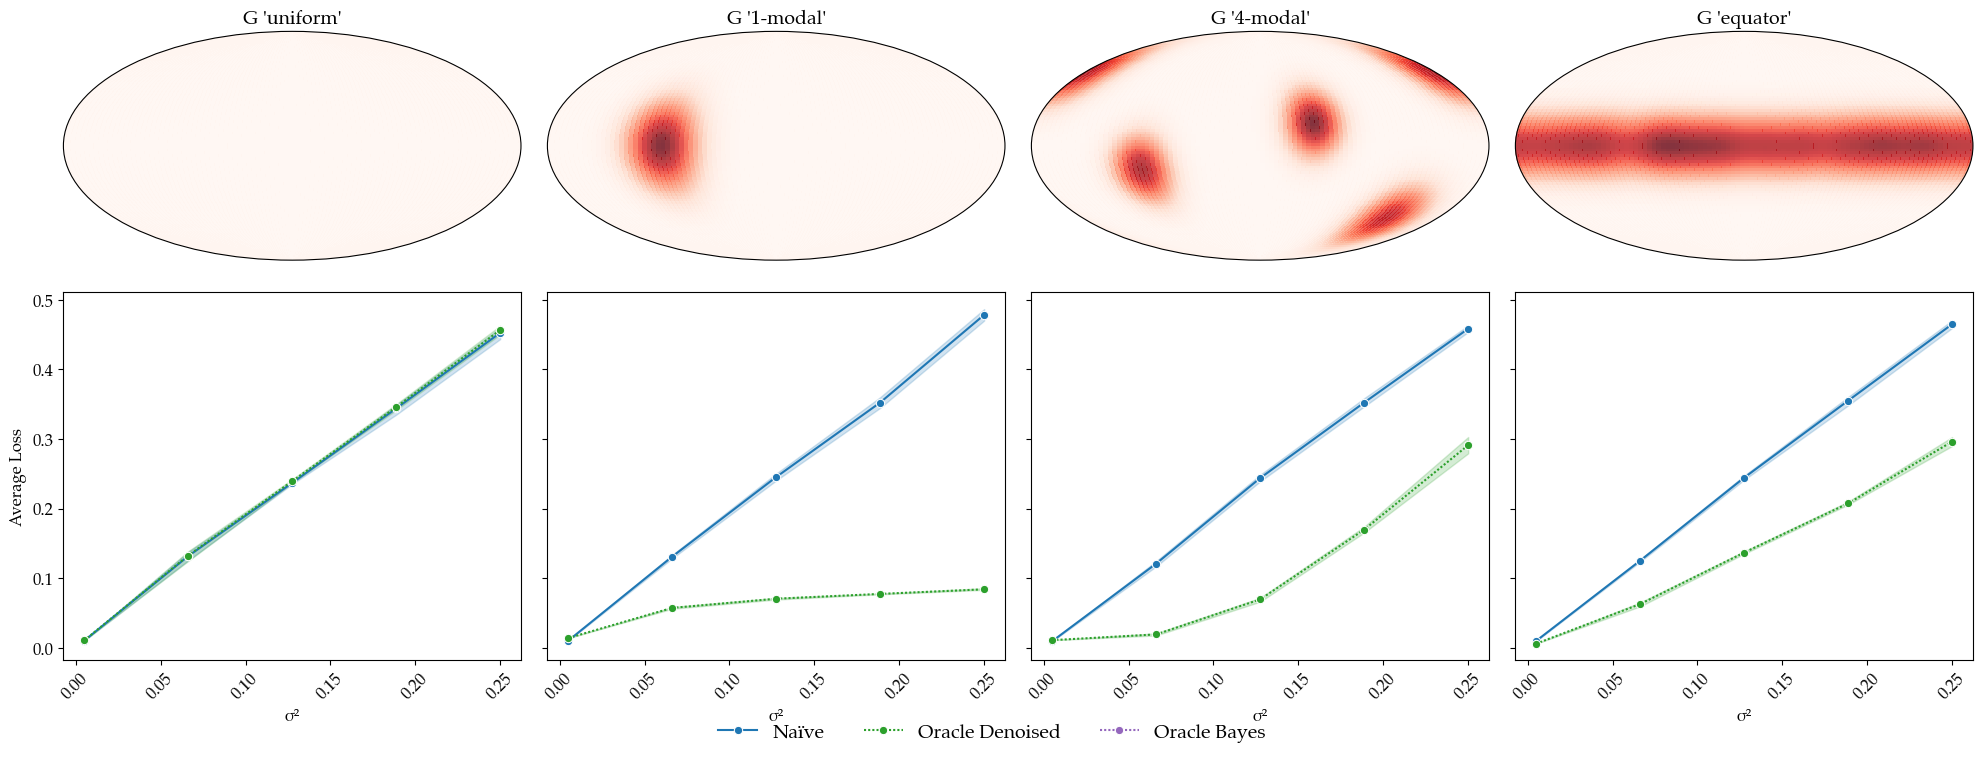

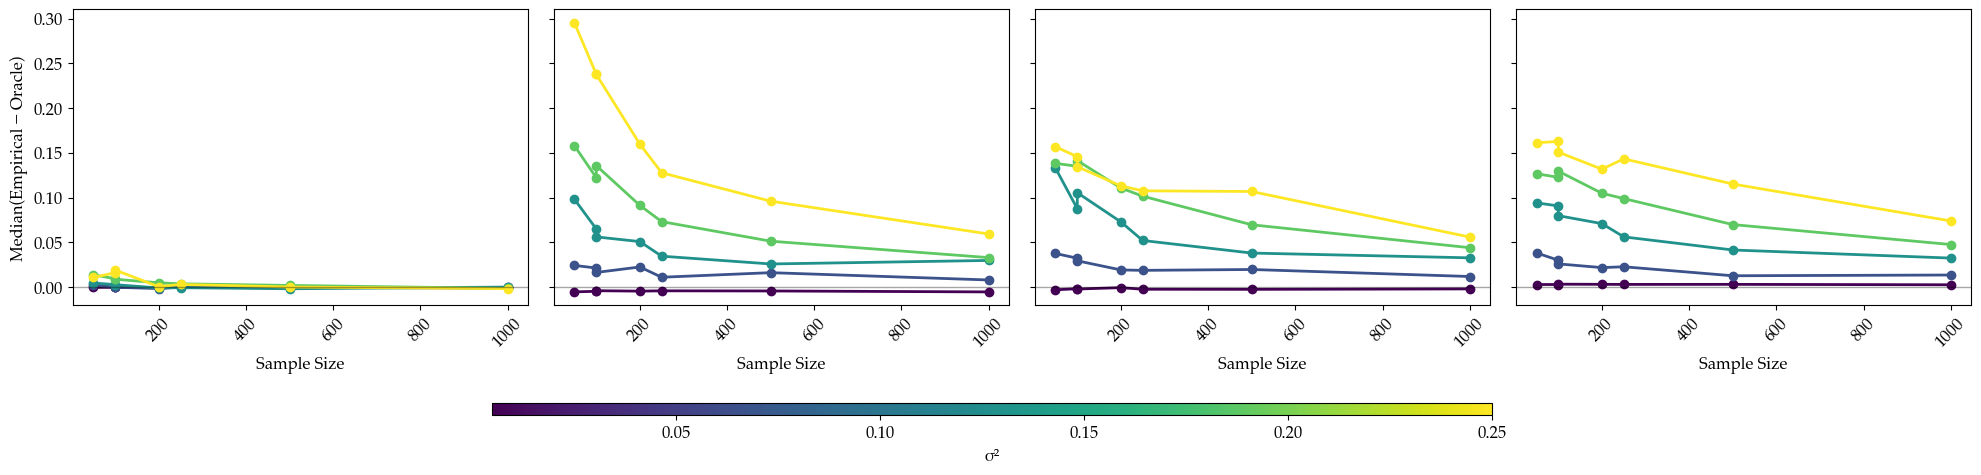

In [19]:
plot_mcsims_IncreasingSigma(
    manifold_type, 
    df_sigma, 
    G_sampler_ls,
    savefig = None)
plot_mcsims_IncreasingN(
    manifold_type,
    df_N,
    G_sampler_ls,
    savefig=None,
    sigma_cmap="viridis",
    showG= False)

----

In [ ]:


def mcsims_IncreasingN(
    manifold_type,
    n_samples_ls,
    M_ls,
    G_sampler_ls,
    sigma2_ls,                 
    rho_ls,
    test_size,
    num_oracle_samples,
    oracle_bandwidth,
    NMC,
):
    if manifold_type == "S1":
        manifold = Hypersphere(1)
    elif manifold_type == "S2":
        manifold = Hypersphere(2)
    elif manifold_type == "SO3":
        manifold = SpecialOrthogonal(n=3)
    else:
        raise ValueError("Unsupported manifold type. Supported types are 'S1', 'S2', and 'SO3'.")

    all_records = []

    for sigma2 in sigma2_ls:
        # store chosen rho* for each G across n_samples
        rho_stars = {G.name: np.zeros(len(n_samples_ls)) for G in G_sampler_ls}

        for G, M in zip(G_sampler_ls, M_ls):
            for ixn, n_samples in enumerate(n_samples_ls):

                # we will only keep Empirical and Oracle (for diff)
                oracle_losses = np.zeros(NMC)
                delta_by_rho_losses = np.zeros((NMC, len(rho_ls)))

                for imc in tqdm(range(NMC), desc=f'G "{G.name}", sigma2={sigma2}, n={n_samples}', leave=False):
                    test_Theta = G.sample(test_size)
                    test_X = manifold.random_riemannian_normal(test_Theta, 1.0 / sigma2, test_size)

                    Theta = G.sample(n_samples)
                    X = manifold.random_riemannian_normal(Theta, 1.0 / sigma2, n_samples)

                    for ixrho, rho in enumerate(rho_ls):
                        delta = denoiser(manifold_type, X, M, rho, sigma2, test_X)
                        delta_by_rho_losses[imc, ixrho] = (
                            manifold.metric.dist_broadcast(delta, test_Theta) ** 2
                        ).mean()

                    oracle_delta_T = oracle_denoiser(
                        manifold_type,
                        num_oracle_samples,
                        sigma2,
                        oracle_bandwidth,
                        test_X,
                        G.sample,
                    )
                    oracle_losses[imc] = (
                        manifold.metric.dist_broadcast(oracle_delta_T, test_Theta) ** 2
                    ).mean()

                # select rho* using mean Empirical Denoised loss across MC (same as before)
                rho_star_idx = int(np.argmin(delta_by_rho_losses.mean(axis=0)))
                rho_star = float(rho_ls[rho_star_idx])
                rho_stars[G.name][ixn] = rho_star

                empirical_losses = delta_by_rho_losses[:, rho_star_idx]
                diff = empirical_losses - oracle_losses  # Empirical - Oracle, per MC iter

                all_records.append(
                    {
                        "G": G.name,
                        "sigma2": float(sigma2),
                        "num_samples": int(n_samples),
                        "rho_star": rho_star,
                        "median_emp_minus_oracle": float(np.mean(diff)),
                        "std_emp_minus_oracle": float(np.std(diff)),
                    }
                )

    return pd.DataFrame(all_records)

In [ ]:
NMC = 10
rho_ls = np.linspace(0.5, 0.005, 10)
M_ls = [ 7,7,7,7 ]

n_samples_ls = [50, 100, 200, 250, 500,1000]
test_size = 100
# ------------------------------------------------------------------------------------------------------------------------------------------------
df_N = mcsims_IncreasingN(
    manifold_type,
    n_samples_ls,
    M_ls,
    G_sampler_ls,
    sigma2_ls,
    rho_ls,
    test_size,
    num_oracle_samples,
    oracle_bandwidth,
    NMC)


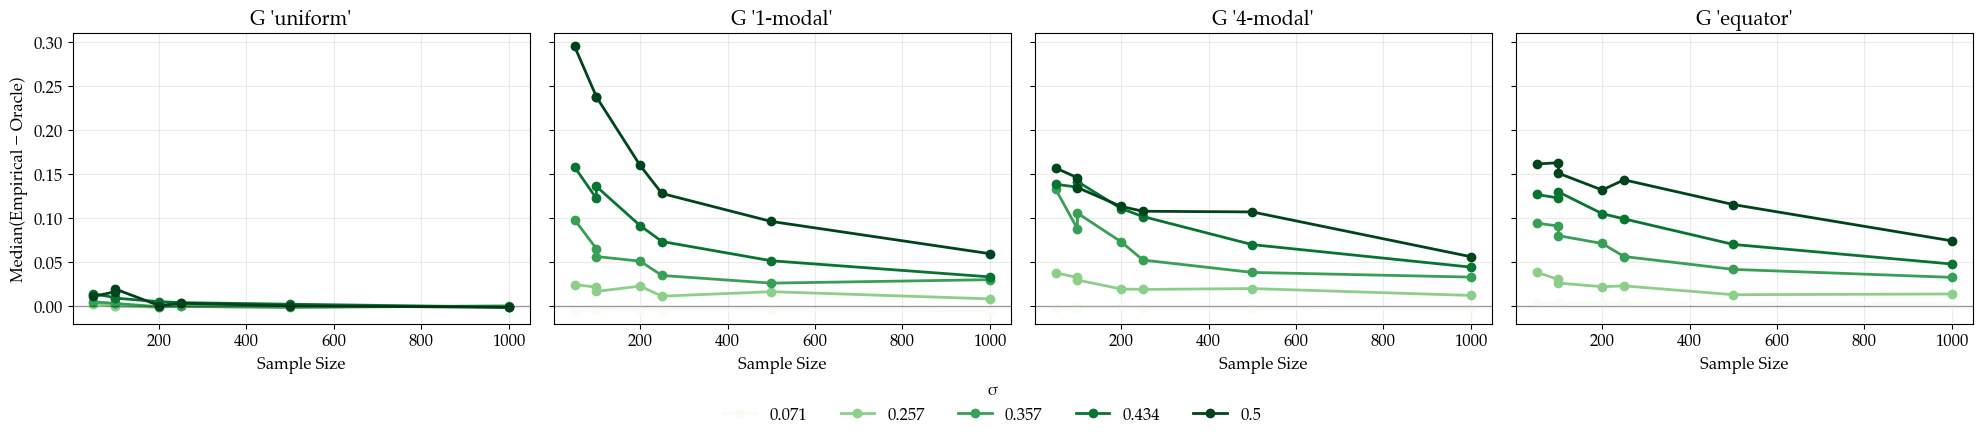

In [79]:
plot_mcsims_IncreasingN(
    manifold_type,
    df_N,
    G_sampler_ls,
    savefig=None,
    showG= False)

In [78]:
from matplotlib.lines import Line2D

def plot_mcsims_IncreasingN(
    manifold_type,
    df_summary,
    G_sampler_ls,
    savefig=None,
    sigma_cmap="Greens",
    showG=True,
):
    fig, axs = plt.subplots(1, len(G_sampler_ls), figsize=(20, 4), sharey=True)
    if len(G_sampler_ls) == 1:
        axs = [axs]

    # color mapping for sigma (not sigma^2)
    sigma2_vals = np.sort(df_summary["sigma2"].unique())
    sigma_vals = np.sqrt(sigma2_vals)

    norm = mpl.colors.Normalize(vmin=float(np.min(sigma_vals)), vmax=float(np.max(sigma_vals)))
    cmap = mpl.cm.get_cmap(sigma_cmap)

    for idx, G in enumerate(G_sampler_ls):
        ax = axs[idx]
        df_g = df_summary[df_summary["G"] == G.name].copy()

        for sigma2 in sigma2_vals:
            d = df_g[df_g["sigma2"] == sigma2].sort_values("num_samples")
            if d.empty:
                continue

            sigma = float(np.sqrt(sigma2))
            color = cmap(norm(sigma))

            x = d["num_samples"].to_numpy()
            y = d["median_emp_minus_oracle"].to_numpy()
            ax.plot(x, y, color=color, marker="o", linewidth=2)

        ax.axhline(0.0, color="k", linewidth=1, alpha=0.35)
        ax.set_title(f"G '{G.name}'")
        ax.set_xlabel("Sample Size")
        if idx == 0:
            ax.set_ylabel("Median(Empirical − Oracle)")
        ax.tick_params(axis="x", rotation=0)
        ax.grid(True, alpha=0.25)

    # shared colorbar for sigma
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    # shared colorbar for sigma (place it below all subplots)
    # shared legend for sigma (instead of colorbar)

    # choose a small set of sigma values to show in the legend
    sigma_legend_vals = np.unique(np.round(sigma_vals, 3))

    legend_handles = [
        Line2D([0], [0], color=cmap(norm(float(s))), marker="o", linewidth=2, label=f"{s:g}")
        for s in sigma_legend_vals
    ]

    fig.legend(
        handles=legend_handles,
        title="σ",
        loc="lower center",
        ncol=len(legend_handles),
        frameon=False,
        bbox_to_anchor=(0.5, -0.12),
    )

    plt.tight_layout()
    if savefig is not None:
        plt.savefig(f"{savefig}", bbox_inches="tight")
    plt.show()
    return None


-------

In [13]:
from utils import *

def plot_mcsims_IncreasingSigma(manifold_type, df_long, G_sampler_ls, savefig=None):
    fig, axs = plt.subplots(2, len(G_sampler_ls), figsize=(20, 8))

    for idx, G in enumerate(G_sampler_ls):

        if manifold_type == "S1":
            manifold = Hypersphere(1)
            axs[0, idx].remove()
            axs[0, idx] = fig.add_subplot(2, len(G_sampler_ls), idx + 1, polar=True)
            Theta = G.sample(1000)
            Theta = manifold.intrinsic_to_extrinsic_coords(
                manifold.extrinsic_to_intrinsic_coords(Theta) - np.pi/12
            )
            S1_histogram(Theta, 30, axs[0, idx], "Reds")

        elif manifold_type == "S2":
            manifold = Hypersphere(2)
            axs[0, idx].remove()
            axs[0, idx] = fig.add_subplot(2, len(G_sampler_ls), 1 + idx, projection="mollweide")
            axs[0, idx].set_xticks([]); axs[0, idx].set_yticks([])
            axs[0, idx].grid(True, alpha=0.3)
            axs[0, idx].set_title(f"G '{G.name}'", fontsize=14)
            grid_resolution = 100
            grid, grid_theta, grid_phi = S2grid(grid_resolution)
            hat_f =  kernel_density_estimate("S2", G.sample(1000), 20, grid)[1].reshape(grid_resolution, grid_resolution)
            im = axs[0, idx].pcolormesh(
                grid_phi - np.pi,
                np.pi / 2 - grid_theta,
                hat_f,
                alpha=0.8,
                shading="auto",
                cmap="Reds",
                vmin= .5 if G.name == 'uniform' else None, vmax = .5 if G.name == 'uniform' else None
                )

        else:
            raise ValueError("Unsupported manifold type. Supported types are 'S1' and 'S2'.")

        # ... your second row plotting code unchanged ...
        df_subset = df_long[df_long["G"] == G.name]
        sns.lineplot(
            data=df_subset,
            x="sigma2",
            y="Loss",
            hue="Loss Type",
            hue_order=[
                "Naïve", 
                # "Empirical Denoised",
                "Oracle Denoised", 
                "Oracle Bayes"
                ],
            palette={
                "Naïve": "C0",
                # "Empirical Denoised": "C2",
                "Oracle Denoised": "C2",
                "Oracle Bayes": "C4",
            },
            style="Loss Type",
            dashes={
                "Naïve": "",
                # "Empirical Denoised": "",
                "Oracle Denoised": (1, 1),
                "Oracle Bayes": (1, 1),
            },
            estimator="mean",
            errorbar=("ci", 68),
            marker="o",
            ax=axs[1, idx],
        )

        handles, labels = axs[1, idx].get_legend_handles_labels()
        labels_mapper = {
            "Naïve": "$\delta_N$",
            "Empirical Denoised": "\hat\delta_T",
            "Oracle Denoised": "$\delta_T$",
            "Oracle Bayes": "$\delta_B$"
        }
        labels = [labels_mapper[label] for label in labels]
        axs[1, idx].get_legend().remove()
        if idx == len(G_sampler_ls) - 1:
            fig.legend(handles, labels, loc="lower center", ncol=len(labels), frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize = 14)

        axs[1, idx].set_xlabel("σ²")
        axs[1, idx].set_ylabel("Average Loss")
        axs[1, idx].tick_params(axis="x", rotation=45)

        base = axs[1, 0]
        for c in range(1, axs.shape[1]):
            axs[1, c].sharey(base)
            axs[1, c].set_ylabel("")
            axs[1, c].tick_params(labelleft=False)


    plt.tight_layout()
    if savefig is not None:
        plt.savefig(f"{savefig}", bbox_inches="tight")
    plt.show()
    return None


def plot_mcsims_IncreasingN(
    manifold_type,
    df_summary,
    G_sampler_ls,
    savefig=None,
    sigma_cmap="viridis",
    showG = True
):
    """
    Plot outcome of mcsims_IncreasingN_summary (median/std of Empirical-Oracle),
    with one column per G and sigma2 encoded by a colorscale + colorbar.

    Expected df_summary columns:
      - G
      - sigma2
      - num_samples
      - rho_star
      - median_emp_minus_oracle
      - std_emp_minus_oracle
    """
    fig, axs = plt.subplots(2 if showG else 1, len(G_sampler_ls), figsize=(20, 8 if showG else 4))

    # ---- color mapping for sigma2 (shared across all panels) ----
    sigma2_vals = np.sort(df_summary["sigma2"].unique())
    norm = mpl.colors.Normalize(vmin=float(np.min(sigma2_vals)), vmax=float(np.max(sigma2_vals)))
    cmap = mpl.cm.get_cmap(sigma_cmap)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    for idx, G in enumerate(G_sampler_ls):
        if showG:
            # ===== row 0: show the target distribution for this G (same style as your other plot) =====
            if manifold_type == "S1":
                manifold = Hypersphere(1)
                axs[0, idx].remove()
                axs[0, idx] = fig.add_subplot(2, len(G_sampler_ls), idx + 1, polar=True)
                Theta = G.sample(1000)
                Theta = manifold.intrinsic_to_extrinsic_coords(
                    manifold.extrinsic_to_intrinsic_coords(Theta) - np.pi / 12
                )
                S1_histogram(Theta, 30, axs[0, idx], "Reds")
                axs[0, idx].set_title(f"G '{G.name}'", fontsize=14)

            elif manifold_type == "S2":
                manifold = Hypersphere(2)
                axs[0, idx].remove()
                axs[0, idx] = fig.add_subplot(2, len(G_sampler_ls), 1 + idx, projection="mollweide")
                axs[0, idx].set_xticks([])
                axs[0, idx].set_yticks([])
                axs[0, idx].grid(True, alpha=0.3)
                axs[0, idx].set_title(f"G '{G.name}'", fontsize=14)

                grid_resolution = 100
                grid, grid_theta, grid_phi = S2grid(grid_resolution)
                hat_f = kernel_density_estimate("S2", G.sample(1000), 20, grid)[1].reshape(
                    grid_resolution, grid_resolution
                )
                axs[0, idx].pcolormesh(
                    grid_phi - np.pi,
                    np.pi / 2 - grid_theta,
                    hat_f,
                    alpha=0.8,
                    shading="auto",
                    cmap="Reds",
                    vmin=0.5 if G.name == "uniform" else None,
                    vmax=0.5 if G.name == "uniform" else None,
                )
            else:
                raise ValueError("Unsupported manifold type. Supported types are 'S1' and 'S2'.")

        # ===== row 1: plot median diff vs N, colored by sigma2 =====
        ax = axs[1, idx] if showG else axs[idx]
        df_g = df_summary[df_summary["G"] == G.name].copy()

        for sigma2 in sigma2_vals:
            d = df_g[df_g["sigma2"] == sigma2].sort_values("num_samples")
            if len(d) == 0:
                continue

            color = cmap(norm(float(sigma2)))
            x = d["num_samples"].to_numpy()
            y = d["median_emp_minus_oracle"].to_numpy()


            ax.plot(x, y, color=color, marker="o", linewidth=2)
            # s = d["std_emp_minus_oracle"].to_numpy()
            # ax.fill_between(x, y - s, y + s, color=color, alpha=0.20, linewidth=0)

        ax.axhline(0.0, color="k", linewidth=1, alpha=0.35)
        ax.set_xlabel("Sample Size")
        ax.set_ylabel("Median(Empirical − Oracle)")
        ax.tick_params(axis="x", rotation=45)

        # share y across bottom row
        base = axs[1, 0] if showG else axs[0]
        for c in range(1, len(G_sampler_ls)):
            axs[1, c].sharey(base) if showG else axs[c].sharey(base)
            axs[1, c].set_ylabel("") if showG else axs[c].set_ylabel("")
            axs[1, c].tick_params(labelleft=False) if showG else axs[c].tick_params(labelleft=False)

    # ---- shared colorbar for sigma2 ----
    # ---- shared colorbar for sigma2 ----
    # Create a dedicated axes for the colorbar so tight_layout won't move it weirdly.
    plt.tight_layout()

    cax = fig.add_axes([0.25, -0.06, 0.50, 0.03])  # [left, bottom, width, height] in figure coords
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label("σ²")

    
    if savefig is not None:
        plt.savefig(f"{savefig}", bbox_inches="tight")
    plt.show()
    return None

# sns.lineplot(
#             data=df_long[df_long['num_modes'] == num_modes],
#             x="num_samples",
#             y="Loss",
#             hue="Loss Type",
#             hue_order=["Naïve","Empirical Denoised", "Oracle Denoised", "Oracle Bayes"],
#             palette={
#                 "Naïve": "C0",
#                 "Empirical Denoised": "C2",
#                 "Oracle Denoised": "C2",
#                 "Oracle Bayes": "C4",
#             },
#             style="Loss Type",  # map linestyle to hue categories
#             dashes={
#                 "Naïve": "",
#                 "Empirical Denoised": "",
#                 "Oracle Denoised": (1, 1),
#                 "Oracle Bayes": (1, 1),
#             },
#             estimator="mean",
#             errorbar=("ci", 68),  # 1-sigma style band
#             marker="o",
#             ax=axs[1, idx],
#         )

-------